# 04 — ASRS XGBoost Signal Filter

## Goal
Train an XGBoost binary classifier that predicts whether an ASRS trade will be a winner.
Only trade when **P(win) > threshold**, filtering out low-probability setups.

### Pipeline
1. Load the ASRS trade log (`data/asrs_trades_all.csv`) produced by notebook 01.
2. Engineer features from the raw 5-min DAX data (signal bar shape, ATR, gap, morning range, etc.).
3. Train XGBoost with 5-fold stratified cross-validation; tune the probability threshold.
4. Compare filtered vs unfiltered equity curves and walk-forward performance.
5. Save the model for live filtering.

> Baseline (unfiltered): **WR 28.2%, PF 1.08** over 5,135 trades 2006-2026.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import LabelEncoder
try:
    import xgboost as xgb
except ImportError:
    raise ImportError(
        "xgboost is not installed. Run: pip install xgboost  (or: uv add xgboost)"
    )
import joblib
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f'ROOT = {ROOT}')

ROOT = C:\Users\ali\Desktop\Projet-INFO-2AS2


In [2]:
# ── Load trades ──────────────────────────────────────────────────────────────
trades_path = ROOT / 'data' / 'asrs_trades_all.csv'
assert trades_path.exists(), (
    f"Trades file not found: {trades_path}\n"
    "Run notebook 01_asrs_baseline.ipynb first to generate it."
)

trades_raw = pd.read_csv(trades_path, parse_dates=['trade_date'])
trades_df = trades_raw[trades_raw['variant'] == 'ASRS_4th'].copy()
trades_df = trades_df.sort_values('trade_date').reset_index(drop=True)
print(f'Total trades (ASRS_4th): {len(trades_df):,}')
print(f'Date range: {trades_df["trade_date"].min().date()} → {trades_df["trade_date"].max().date()}')

# ── Load raw 5-min data ───────────────────────────────────────────────────────
raw_path = ROOT / 'data' / 'dax-5m_bk.csv'
assert raw_path.exists(), f"Raw data not found: {raw_path}"

raw_df = pd.read_csv(
    raw_path,
    sep=';',
    header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
    dtype={'date': str, 'time': str,
           'open': float, 'high': float, 'low': float,
           'close': float, 'volume': float}
)
raw_df['dt'] = pd.to_datetime(
    raw_df['date'] + ' ' + raw_df['time'],
    format='%d/%m/%Y %H:%M'
)
raw_df = raw_df.sort_values('dt').reset_index(drop=True)
raw_df['date_only'] = raw_df['dt'].dt.date

print(f'\nRaw 5-min rows: {len(raw_df):,}')
print(f'Raw date range: {raw_df["dt"].min()} → {raw_df["dt"].max()}')

Total trades (ASRS_4th): 5,135
Date range: 2006-01-02 → 2026-04-02



Raw 5-min rows: 1,182,771
Raw date range: 2000-06-16 02:50:00 → 2026-04-06 23:50:00


In [3]:
def _true_range(df: pd.DataFrame) -> pd.Series:
    """True range for a bar DataFrame with columns high/low/close."""
    prev_close = df['close'].shift(1)
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev_close).abs(),
        (df['low'] - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr


def build_features(trades_df: pd.DataFrame, raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each trade in trades_df, look up the raw 5-min bars around the
    09:15 CET signal bar on trade_date and compute features.

    Returns a DataFrame of features + target column 'winner'.
    """
    # Pre-index raw data by date for fast lookups
    raw_df = raw_df.copy()
    raw_df['day'] = pd.to_datetime(raw_df['date_only'])
    grouped = {day: grp.reset_index(drop=True)
               for day, grp in raw_df.groupby('day')}

    # Build daily high/low for prev_day_range
    daily = raw_df.groupby('day').agg(
        day_high=('high', 'max'),
        day_low=('low', 'min'),
        day_last_close=('close', 'last')
    ).reset_index().sort_values('day')
    daily['prev_day_range'] = daily['day_high'] - daily['day_low']
    daily['prev_day_last_close'] = daily['day_last_close'].shift(1)
    daily['prev_day_range_val'] = daily['prev_day_range'].shift(1)
    daily = daily.set_index('day')

    rows = []
    for _, trade in trades_df.iterrows():
        td = pd.Timestamp(trade['trade_date']).normalize()
        row = {}

        # ── features already in trades ──────────────────────────────────────
        row['sig_range'] = trade['sig_range']
        row['bar_used'] = trade['bar_used'] if pd.notna(trade.get('bar_used')) else 0
        row['direction_enc'] = 1 if str(trade['direction']).lower() in ('long', 'buy') else 0
        row['dow'] = td.dayofweek          # 0=Mon, 4=Fri
        row['month'] = td.month

        day_bars = grouped.get(td)
        if day_bars is None or len(day_bars) == 0:
            # No raw data for this day — fill with NaN, handled later
            for k in ['sig_range_norm', 'bar_body_ratio', 'wick_upper_ratio',
                      'wick_lower_ratio', 'bar_bullish', 'atr14_abs',
                      'prev_day_range', 'gap_pts', 'morning_range',
                      'morning_direction', 'price_vs_ma20']:
                row[k] = np.nan
            row['winner'] = 1 if trade['pnl'] > 0 else 0
            rows.append(row)
            continue

        # ── locate signal bar at 09:15 ───────────────────────────────────────
        sig_mask = day_bars['dt'].dt.hour * 60 + day_bars['dt'].dt.minute == 9 * 60 + 15
        sig_bars = day_bars[sig_mask]
        if len(sig_bars) == 0:
            sig_bar = None
        else:
            sig_bar = sig_bars.iloc[0]

        # ── bars BEFORE signal bar (for ATR/MA) ─────────────────────────────
        sig_idx = sig_bars.index[0] if len(sig_bars) > 0 else None
        if sig_idx is not None and sig_idx >= 14:
            pre_bars = day_bars.loc[:sig_idx]       # include signal bar
        elif sig_idx is not None:
            # Try to use previous day bars too (just use what we have)
            pre_bars = day_bars.loc[:sig_idx]
        else:
            pre_bars = day_bars

        # ATR14 using bars up to and including signal bar
        tr = _true_range(pre_bars)
        atr14 = tr.rolling(14, min_periods=1).mean().iloc[-1]
        row['atr14_abs'] = atr14

        # MA20 on close, up to signal bar
        ma20 = pre_bars['close'].rolling(20, min_periods=1).mean().iloc[-1]

        # ── signal bar features ──────────────────────────────────────────────
        if sig_bar is not None:
            sig_o = sig_bar['open']
            sig_h = sig_bar['high']
            sig_l = sig_bar['low']
            sig_c = sig_bar['close']
            bar_range = sig_h - sig_l
            denom = bar_range if bar_range > 0 else (trade['sig_range'] if trade['sig_range'] > 0 else 1.0)

            row['bar_body_ratio'] = abs(sig_c - sig_o) / denom
            row['wick_upper_ratio'] = (sig_h - max(sig_o, sig_c)) / denom
            row['wick_lower_ratio'] = (min(sig_o, sig_c) - sig_l) / denom
            row['bar_bullish'] = 1 if sig_c > sig_o else 0
            row['price_vs_ma20'] = (sig_c - ma20) / atr14 if atr14 > 0 else 0.0
        else:
            row['bar_body_ratio'] = np.nan
            row['wick_upper_ratio'] = np.nan
            row['wick_lower_ratio'] = np.nan
            row['bar_bullish'] = np.nan
            row['price_vs_ma20'] = np.nan

        # sig_range_norm
        row['sig_range_norm'] = trade['sig_range'] / atr14 if atr14 > 0 else np.nan

        # ── prev_day_range ───────────────────────────────────────────────────
        if td in daily.index:
            row['prev_day_range'] = daily.loc[td, 'prev_day_range_val']
            prev_close = daily.loc[td, 'prev_day_last_close']
        else:
            row['prev_day_range'] = np.nan
            prev_close = np.nan

        # ── gap ──────────────────────────────────────────────────────────────
        open_900_mask = day_bars['dt'].dt.hour * 60 + day_bars['dt'].dt.minute == 9 * 60 + 0
        open_900_bars = day_bars[open_900_mask]
        if len(open_900_bars) > 0 and not np.isnan(prev_close):
            row['gap_pts'] = open_900_bars.iloc[0]['open'] - prev_close
        else:
            row['gap_pts'] = np.nan

        # ── morning range (09:00 → 09:15 inclusive) ──────────────────────────
        morn_mask = (
            (day_bars['dt'].dt.hour * 60 + day_bars['dt'].dt.minute >= 9 * 60 + 0) &
            (day_bars['dt'].dt.hour * 60 + day_bars['dt'].dt.minute <= 9 * 60 + 15)
        )
        morn_bars = day_bars[morn_mask]
        if len(morn_bars) >= 2:
            row['morning_range'] = morn_bars['high'].max() - morn_bars['low'].min()
            row['morning_direction'] = np.sign(
                morn_bars.iloc[-1]['close'] - morn_bars.iloc[0]['open']
            )
        elif len(morn_bars) == 1:
            row['morning_range'] = morn_bars.iloc[0]['high'] - morn_bars.iloc[0]['low']
            row['morning_direction'] = np.sign(
                morn_bars.iloc[0]['close'] - morn_bars.iloc[0]['open']
            )
        else:
            row['morning_range'] = np.nan
            row['morning_direction'] = np.nan

        row['winner'] = 1 if trade['pnl'] > 0 else 0
        rows.append(row)

    feat_df = pd.DataFrame(rows).reset_index(drop=True)

    # ── Handle missing values ────────────────────────────────────────────────
    feat_df = feat_df.ffill().fillna(0)

    # Attach trade_date and pnl for later analysis
    feat_df['trade_date'] = trades_df['trade_date'].values
    feat_df['pnl'] = trades_df['pnl'].values
    feat_df['initial_risk'] = trades_df['initial_risk'].values

    return feat_df


print('build_features() defined — call it in the next cell.')

build_features() defined — call it in the next cell.


In [4]:
print('Building feature matrix (this may take 1-2 min on 5k trades)...')
features_df = build_features(trades_df, raw_df)

print(f'\nFeature matrix shape: {features_df.shape}')

FEATURE_COLS = [
    'sig_range', 'sig_range_norm', 'bar_body_ratio', 'wick_upper_ratio',
    'wick_lower_ratio', 'bar_bullish', 'atr14_abs', 'prev_day_range',
    'gap_pts', 'morning_range', 'morning_direction', 'price_vs_ma20',
    'dow', 'month', 'direction_enc', 'bar_used'
]

# Class balance
n_win  = (features_df['winner'] == 1).sum()
n_loss = (features_df['winner'] == 0).sum()
print(f'\nClass balance:')
print(f'  Winners : {n_win:,}  ({100*n_win/len(features_df):.1f}%)')
print(f'  Losers  : {n_loss:,}  ({100*n_loss/len(features_df):.1f}%)')

# Feature correlations with target
print('\nFeature correlations with winner (Pearson):')
corr = features_df[FEATURE_COLS + ['winner']].corr()['winner'].drop('winner').sort_values(key=abs, ascending=False)
for feat, val in corr.items():
    print(f'  {feat:<22s} {val:+.4f}')

Building feature matrix (this may take 1-2 min on 5k trades)...



Feature matrix shape: (5135, 20)

Class balance:
  Winners : 1,450  (28.2%)
  Losers  : 3,685  (71.8%)

Feature correlations with winner (Pearson):
  sig_range_norm         +0.1334
  bar_body_ratio         +0.0788
  wick_upper_ratio       -0.0715
  direction_enc          +0.0548
  bar_bullish            +0.0469
  prev_day_range         -0.0442
  atr14_abs              -0.0405
  sig_range              +0.0289
  wick_lower_ratio       -0.0265
  gap_pts                +0.0178
  morning_range          -0.0165
  dow                    -0.0049
  morning_direction      +0.0027
  price_vs_ma20          -0.0016
  month                  -0.0000
  bar_used               +nan


In [5]:
# ── Volatility regimes based on ATR14 ────────────────────────────────────────
features_df['vol_regime'] = pd.qcut(
    features_df['atr14_abs'], q=3, labels=['low', 'mid', 'high']
)

print('Trade count and win rate per volatility regime:')
print(f'{"Regime":<8}  {"N trades":>9}  {"Win Rate":>9}  {"Avg ATR14":>10}')
print('-' * 42)
for regime in ['low', 'mid', 'high']:
    mask = features_df['vol_regime'] == regime
    n = mask.sum()
    wr = features_df.loc[mask, 'winner'].mean() * 100
    avg_atr = features_df.loc[mask, 'atr14_abs'].mean()
    print(f'{regime:<8}  {n:>9,}  {wr:>8.1f}%  {avg_atr:>10.1f}')

print('\nNote: vol_regime will be combined with the winner label for stratified CV')
print('to ensure each fold has balanced volatility representation.')

Trade count and win rate per volatility regime:
Regime     N trades   Win Rate   Avg ATR14
------------------------------------------
low           1,712      30.7%         8.8
mid           1,711      28.3%        14.3
high          1,712      25.8%        25.5

Note: vol_regime will be combined with the winner label for stratified CV
to ensure each fold has balanced volatility representation.


In [6]:
FEATURES = FEATURE_COLS
TARGET   = 'winner'
THRESHOLD = 0.40

X = features_df[FEATURES].values
y = features_df[TARGET].values

# Combine vol regime + winner label for stratification
strat_labels = (
    features_df['vol_regime'].astype(str) + '_' + features_df[TARGET].astype(str)
)

scale_pos = (y == 0).sum() / max((y == 1).sum(), 1)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-fold cross-validation...')
oof_probs = cross_val_predict(
    model, X, y,
    cv=cv,
    method='predict_proba',
)[:, 1]

overall_auc = roc_auc_score(y, oof_probs)
print(f'\nOverall OOF AUC: {overall_auc:.4f}')

print('\nPer-fold AUC:')
fold_aucs = []
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, strat_labels)):
    fold_auc = roc_auc_score(y[val_idx], oof_probs[val_idx])
    fold_aucs.append(fold_auc)
    n_val = len(val_idx)
    wr_val = y[val_idx].mean() * 100
    print(f'  Fold {fold_idx+1}: AUC={fold_auc:.4f}  (N={n_val}, WR={wr_val:.1f}%)')
print(f'  Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

Running 5-fold cross-validation...



Overall OOF AUC: 0.5747

Per-fold AUC:
  Fold 1: AUC=0.5938  (N=1027, WR=28.2%)
  Fold 2: AUC=0.5581  (N=1027, WR=28.2%)
  Fold 3: AUC=0.5688  (N=1027, WR=28.2%)
  Fold 4: AUC=0.5664  (N=1027, WR=28.1%)
  Fold 5: AUC=0.5863  (N=1027, WR=28.3%)
  Mean AUC: 0.5747 ± 0.0133


In [7]:
# ── Threshold analysis ────────────────────────────────────────────────────────
thresholds = np.arange(0.30, 0.70, 0.05)

all_pnl  = features_df['pnl'].values
all_wins = features_df['winner'].values

total_pf_baseline = all_pnl[all_pnl > 0].sum() / abs(all_pnl[all_pnl < 0].sum())
total_wr_baseline = all_wins.mean() * 100

print(f'Baseline (no filter):')
print(f'  N={len(all_pnl):,}  WR={total_wr_baseline:.1f}%  PF={total_pf_baseline:.3f}  PnL={all_pnl.sum():+.0f}')
print()

header = f'{"Threshold":>9} {"N kept":>8} {"Filtered%":>10} {"WR%":>7} {"PF":>7} {"Total PnL":>11}'
print(header)
print('-' * len(header))

results = []
for thr in thresholds:
    keep = oof_probs >= thr
    n_kept = keep.sum()
    if n_kept == 0:
        continue
    pnl_kept  = all_pnl[keep]
    wins_kept = all_wins[keep]
    wr  = wins_kept.mean() * 100
    gross_win  = pnl_kept[pnl_kept > 0].sum()
    gross_loss = abs(pnl_kept[pnl_kept < 0].sum())
    pf  = gross_win / gross_loss if gross_loss > 0 else np.inf
    total_pnl = pnl_kept.sum()
    filt_pct  = (1 - n_kept / len(all_pnl)) * 100
    print(f'{thr:>9.2f} {n_kept:>8,} {filt_pct:>9.1f}% {wr:>6.1f}% {pf:>7.3f} {total_pnl:>+11.0f}')
    results.append({'threshold': thr, 'n_kept': n_kept, 'wr': wr, 'pf': pf, 'total_pnl': total_pnl})

results_df = pd.DataFrame(results)

# Best threshold: highest PF with >= 200 trades remaining
valid = results_df[results_df['n_kept'] >= 200]
if len(valid) > 0:
    best_row = valid.loc[valid['pf'].idxmax()]
    BEST_THRESHOLD = best_row['threshold']
    print(f'\nBest threshold (PF-maximising, N>=200): {BEST_THRESHOLD:.2f}')
    print(f'  N={int(best_row["n_kept"]):,}  WR={best_row["wr"]:.1f}%  PF={best_row["pf"]:.3f}  PnL={best_row["total_pnl"]:+.0f}')
else:
    BEST_THRESHOLD = THRESHOLD
    print(f'No threshold with N>=200 found; using default {BEST_THRESHOLD}')

Baseline (no filter):
  N=5,135  WR=28.2%  PF=1.082  PnL=+6029

Threshold   N kept  Filtered%     WR%      PF   Total PnL
---------------------------------------------------------
     0.30    4,325      15.8%   29.7%   1.083       +5176
     0.35    3,796      26.1%   30.4%   1.108       +5856
     0.40    3,228      37.1%   31.4%   1.118       +5401
     0.45    2,548      50.4%   32.7%   1.147       +5150
     0.50    1,893      63.1%   34.2%   1.179       +4637
     0.55    1,305      74.6%   33.9%   1.097       +1738
     0.60      795      84.5%   35.6%   1.201       +2206
     0.65      409      92.0%   39.1%   1.237       +1311

Best threshold (PF-maximising, N>=200): 0.65
  N=409  WR=39.1%  PF=1.237  PnL=+1311


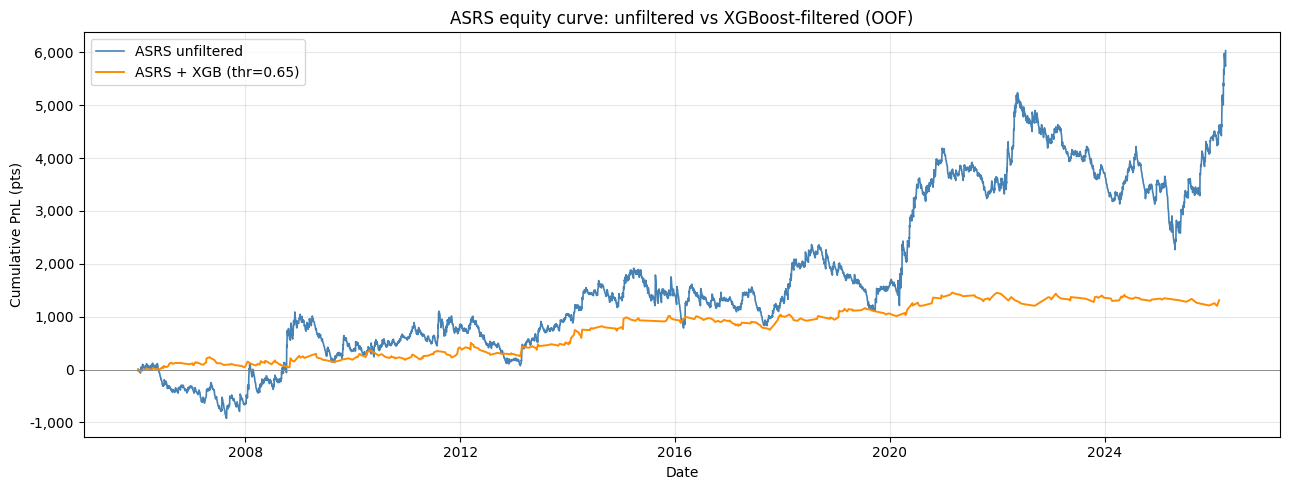


Unfiltered:  N=5,135  PnL=+6029
Filtered:    N=409  PnL=+1311


In [8]:
# ── Equity curves: filtered vs unfiltered ────────────────────────────────────
filter_mask = oof_probs >= BEST_THRESHOLD

pnl_all      = features_df['pnl'].values
pnl_filtered = np.where(filter_mask, pnl_all, 0.0)

cum_all      = np.cumsum(pnl_all)
cum_filtered = np.cumsum(pnl_filtered[filter_mask])   # only active trades
dates_all    = pd.to_datetime(features_df['trade_date'])
dates_filt   = dates_all[filter_mask]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_all,  cum_all,      linewidth=1.2, label='ASRS unfiltered', color='steelblue')
ax.plot(dates_filt, cum_filtered, linewidth=1.4, label=f'ASRS + XGB (thr={BEST_THRESHOLD:.2f})', color='darkorange')
ax.axhline(0, color='grey', linewidth=0.6)
ax.set_title('ASRS equity curve: unfiltered vs XGBoost-filtered (OOF)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative PnL (pts)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f'\nUnfiltered:  N={len(pnl_all):,}  PnL={cum_all[-1]:+.0f}')
print(f'Filtered:    N={filter_mask.sum():,}  PnL={cum_filtered[-1] if len(cum_filtered)>0 else 0:+.0f}')

Fitting final model on full dataset...


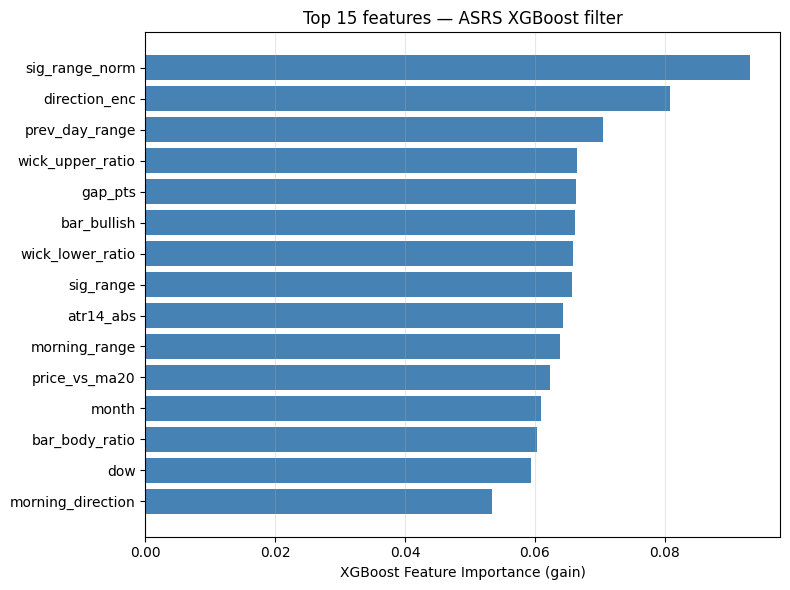


Top 15 features:
Rank  Feature                     Importance
--------------------------------------------
1     sig_range_norm                 0.09313
2     direction_enc                  0.08079
3     prev_day_range                 0.07046
4     wick_upper_ratio               0.06650
5     gap_pts                        0.06638
6     bar_bullish                    0.06622
7     wick_lower_ratio               0.06591
8     sig_range                      0.06577
9     atr14_abs                      0.06432
10    morning_range                  0.06390
11    price_vs_ma20                  0.06242
12    month                          0.06095
13    bar_body_ratio                 0.06041
14    dow                            0.05948
15    morning_direction              0.05336


In [9]:
# ── Feature importance: fit on full dataset ───────────────────────────────────
print('Fitting final model on full dataset...')
model.fit(X, y)

importances = model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue')
ax.set_xlabel('XGBoost Feature Importance (gain)')
ax.set_title('Top 15 features — ASRS XGBoost filter')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(f'{"Rank":<5} {"Feature":<25} {"Importance":>12}')
print('-' * 44)
for rank, (_, row) in enumerate(feat_imp_df.iterrows(), 1):
    print(f'{rank:<5} {row["feature"]:<25} {row["importance"]:>12.5f}')

In [10]:
# ── Performance by volatility regime ─────────────────────────────────────────
def regime_stats(mask, label):
    pnl   = features_df.loc[mask, 'pnl'].values
    wins  = features_df.loc[mask, 'winner'].values
    if len(pnl) == 0:
        return f'{label:<20} {0:>8}  {0:>7.1f}%  {0:>7.3f}  {0:>+12.0f}'
    wr   = wins.mean() * 100
    gw   = pnl[pnl > 0].sum()
    gl   = abs(pnl[pnl < 0].sum())
    pf   = gw / gl if gl > 0 else np.inf
    tot  = pnl.sum()
    return f'{label:<20} {len(pnl):>8,}  {wr:>7.1f}%  {pf:>7.3f}  {tot:>+12.0f}'

print(f'{"Label":<20} {"N":>8}  {"WR":>7}  {"PF":>7}  {"PnL":>12}')
print('-' * 62)

for regime in ['low', 'mid', 'high']:
    regime_mask = features_df['vol_regime'] == regime
    filt_and_regime = regime_mask & filter_mask

    print(regime_stats(regime_mask,          f'{regime.upper()} VOL unfilt'))
    print(regime_stats(filt_and_regime,       f'{regime.upper()} VOL filtered'))
    print()

Label                       N       WR       PF           PnL
--------------------------------------------------------------
LOW VOL unfilt          1,712     30.7%    1.119         +1743
LOW VOL filtered          183     39.9%    1.416          +697

MID VOL unfilt          1,711     28.3%    1.000            -5
MID VOL filtered          151     39.1%    1.199          +421

HIGH VOL unfilt         1,712     25.8%    1.116         +4291
HIGH VOL filtered          75     37.3%    1.112          +193



In [11]:
# ── Walk-forward validation: train 2006-2019, test 2020-2026 ─────────────────
TRAIN_END = pd.Timestamp('2019-12-31')
TEST_START = pd.Timestamp('2020-01-01')

dates = pd.to_datetime(features_df['trade_date'])
train_mask = dates <= TRAIN_END
test_mask  = dates >= TEST_START

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train set (2006-2019): {train_mask.sum():,} trades')
print(f'Test  set (2020-2026): {test_mask.sum():,} trades')

# Refit on train only
scale_pos_train = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
wf_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=scale_pos_train,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
wf_model.fit(X_train, y_train)
wf_probs_test = wf_model.predict_proba(X_test)[:, 1]

wf_filter = wf_probs_test >= BEST_THRESHOLD
pnl_test_all   = features_df.loc[test_mask, 'pnl'].values
wins_test_all  = features_df.loc[test_mask, 'winner'].values
pnl_test_filt  = pnl_test_all[wf_filter]
wins_test_filt = wins_test_all[wf_filter]

def pf(pnl_arr):
    gw = pnl_arr[pnl_arr > 0].sum()
    gl = abs(pnl_arr[pnl_arr < 0].sum())
    return gw / gl if gl > 0 else np.inf

print()
print('Walk-Forward results (test period 2020-2026):')
print(f'{"":<22} {"N":>7} {"WR%":>7} {"PF":>7} {"PnL":>11}')
print('-' * 56)
print(f'{"ASRS unfiltered":<22} '
      f'{len(pnl_test_all):>7,} '
      f'{wins_test_all.mean()*100:>6.1f}% '
      f'{pf(pnl_test_all):>7.3f} '
      f'{pnl_test_all.sum():>+11.0f}')
if len(pnl_test_filt) > 0:
    print(f'{"ASRS + XGB filter":<22} '
          f'{len(pnl_test_filt):>7,} '
          f'{wins_test_filt.mean()*100:>6.1f}% '
          f'{pf(pnl_test_filt):>7.3f} '
          f'{pnl_test_filt.sum():>+11.0f}')
else:
    print('No trades passed filter on test set.')

if len(pnl_test_all) > 0 and len(pnl_test_filt) > 0:
    test_auc = roc_auc_score(y_test, wf_probs_test)
    print(f'\nWalk-forward test AUC: {test_auc:.4f}')

Train set (2006-2019): 3,541 trades
Test  set (2020-2026): 1,594 trades

Walk-Forward results (test period 2020-2026):
                             N     WR%      PF         PnL
--------------------------------------------------------
ASRS unfiltered          1,594   27.5%   1.151       +4445
ASRS + XGB filter           88   33.0%   0.966         -65

Walk-forward test AUC: 0.5714


In [12]:
# ── Save model ────────────────────────────────────────────────────────────────
model.fit(X, y)
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump(model,    models_dir / 'asrs_xgb_filter.pkl')
joblib.dump(FEATURES, models_dir / 'asrs_xgb_features.pkl')
print(f'Model saved  → models/asrs_xgb_filter.pkl')
print(f'Features     → models/asrs_xgb_features.pkl')
print(f'Threshold    : {BEST_THRESHOLD:.2f}')
print(f'OOF AUC      : {overall_auc:.4f}')
print(f'\nTo load:')
print("  model    = joblib.load('models/asrs_xgb_filter.pkl')")
print("  features = joblib.load('models/asrs_xgb_features.pkl')")
print("  prob = model.predict_proba(X_new)[0, 1]")
print(f"  trade = prob >= {BEST_THRESHOLD:.2f}")

Model saved  → models/asrs_xgb_filter.pkl
Features     → models/asrs_xgb_features.pkl
Threshold    : 0.65
OOF AUC      : 0.5747

To load:
  model    = joblib.load('models/asrs_xgb_filter.pkl')
  features = joblib.load('models/asrs_xgb_features.pkl')
  prob = model.predict_proba(X_new)[0, 1]
  trade = prob >= 0.65
